In [1]:
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering, Rotations, ImageTransformations, CoordinateTransformations
using Statistics

In [285]:
function smooth_imgs(img, size_kernel)
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function normalize(img)
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function find_stripe_radius_range(img, stripe_major_axis_range, stripe_minor_axis_range, threshold_stripes)
    blob_centers, major_axis_blobs, minor_axis_blobs = [], [], []
    response = zeros(size(img))
    

    for i in 1:length(stripe_major_axis_range)
        for j in 1:length(stripe_minor_axis_range)
            log_kernel = Kernel.gaussian((stripe_minor_axis_range[j], stripe_major_axis_range[i]))

            response .+= imfilter(img, log_kernel) .* stripe_minor_axis_range[j]*stripe_major_axis_range[i]
        end
    end

    blobs = response .> threshold_stripes * std(img) # Adaptative threshold depending on the std of the img

    label_blobs = label_components(blobs) # Separate the blobs
    for label in 1:maximum(label_blobs) # Find the center of each blob
        inds = findall(label_blobs .== label)

        if (length(inds) < 2e3) | maximum([maximum([i[1]-1 for i in inds]) - minimum([i[1]-1 for i in inds])]) < 15 # If blob detected is too big, we do not count it (couldn't find angle of stripes/two stripes overlap)
            push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
            push!(major_axis_blobs, [maximum([i[2]-1 for i in inds]) - minimum([i[2]-1 for i in inds])])
            push!(minor_axis_blobs, [maximum([i[1]-1 for i in inds]) - minimum([i[1]-1 for i in inds])])
        end
    end

    return blob_centers, major_axis_blobs, minor_axis_blobs, label_blobs
end

function rotate_img_stripe_angle(img)
    """ Finds the angle at which the stripes are along the horizontal axis,
    ie where a sum along the horizontal axis is maximal """
    θ_range = [0:0.1:π/2;]

    Maximum_hor_mean = zeros(length(θ_range))

    for (i, θ) in enumerate(θ_range)
        trfm = recenter(RotMatrix(θ), center(img))
        imgw = warp(img, trfm)
        imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0

        Maximum_hor_mean[i] = maximum(sum(imgw, dims=2))
    end
    return θ_range[argmax(Maximum_hor_mean)]
end


function mask_ellipse(xc, yc, a, b, θ, width, height)
    mask = zeros(Integer, (width, height))
    X = range(0, height-1) .- yc
    Y = range(0, width-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

mask_ellipse (generic function with 1 method)

### Load the images/ODs

In [ ]:
pathdir = "Y:/TwoDGas/2026/02/06/0000"

@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset

# Droplet parameters
size_kernel_smooth = 5
stripe_major_axis_range = [5:1:20;]
stripe_minor_axis_range = [1:1:2;];

In [301]:
i, j = 5, 1


threshold_stripes = [5000, 2000, 2500, 2600, 2600, 2700, 2800, 2800, 3000, 3000,
                        3100, 3100, 3100, 3100, 3100, 3100, 3200, 3300, 3400] #1550 # 6000

close("all")
fig, axs = subplots(1, 3, figsize=(15, 5))

OD = ODs_dataset[i, j, :, :]
smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
trfm = recenter(RotMatrix(rotate_img_stripe_angle(smooth_norm_OD)), center(smooth_norm_OD))
imgw = parent(warp(smooth_norm_OD, trfm))
imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0
axs[1].imshow(imgw)


# Find the stripes
blob_centers, major_axis_blobs, minor_axis_blobs, label_blobs = find_stripe_radius_range(float.(imgw), stripe_major_axis_range, stripe_minor_axis_range, threshold_stripes[i])

axs[2].imshow(label_blobs)

axs[3].imshow(imgw)

# Draw ellipse for each detected stripe
θ_range = [0:0.01:2π;]
for (i, c) in enumerate(blob_centers)
    axs[3].scatter(c[1], c[2], s=10, marker="x", color="r", alpha=0.4)
    axs[3].plot((major_axis_blobs[i].*cos.(θ_range)).+c[1], (minor_axis_blobs[i].*sin.(θ_range)).+c[2], color="r", alpha=0.4)
end

for ax in axs
    ax.axis("off")
end

# pygui(false);
pygui(true); show();

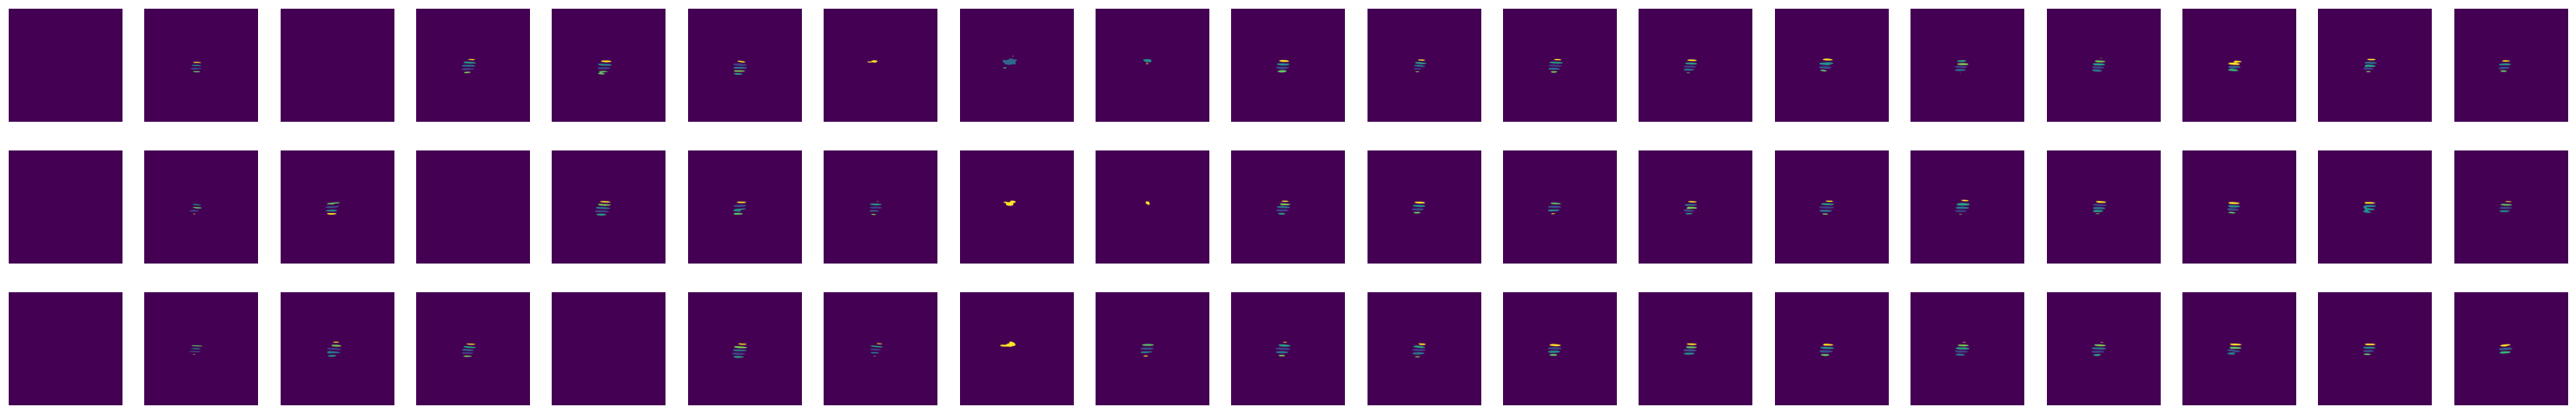

In [286]:
nbr_img_per_sat = 3

close("all")
fig, axs = subplots(nbr_img_per_sat, length(Sat), figsize=(2*length(Sat), 2*nbr_img_per_sat))

for i in 1:length(Sat)
    for j = 1:nbr_img_per_sat
        OD = ODs_dataset[i, j, :, :]
        smooth_OD = smooth_imgs(OD, size_kernel_smooth) # Normalize to gaussian kernel
        smooth_norm_OD = normalize(smooth_norm_OD)
        
        θ = rotate_img_stripe_angle(smooth_norm_OD)
        if (maximum(smooth_OD)-minimum(smooth_OD) > 0.5) & (θ > π/6) # Remove the shots gone wrong and those where the angle couldn't be found
            trfm = recenter(RotMatrix(θ), center(smooth_norm_OD))
            imgw = parent(warp(smooth_norm_OD, trfm))
            imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0
            blob_centers, major_axis_blobs, minor_axis_blobs, label_blobs = find_stripe_radius_range(float.(imgw), stripe_major_axis_range, stripe_minor_axis_range, threshold_stripes[i])

            axs[j, i].imshow(label_blobs)
        end

        for ax in axs
            ax.axis("off")
        end
    end
end

# axis("off")
pygui(false);

# Find the stripes

In [287]:
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes")
end

"Images/2026_02_06_0000/Stripes"

In [298]:
nbr_stripes_ds = zeros(size(ODs_dataset)[1:2])
centers_stripes_ds, major_axis_stripes_ds, minor_axis_stripes_ds = [], [], []
save_imgs = true
θ_range = [0:0.01:2π;]

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for i in ProgressBar(1:length(Sat))
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes/$(Sat[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes/$(Sat[i])")
    end

    centers_stripes, major_axis_stripes, minor_axis_stripes =  [], [], []

    for j = 1:size(ODs_dataset)[2]
        OD = ODs_dataset[i, j, :, :]
        smooth_OD = smooth_imgs(OD, size_kernel_smooth) # Smooth the images with a flat kernel
        smooth_norm_OD = normalize(smooth_OD) # Normalize the images
        θ = rotate_img_stripe_angle(smooth_norm_OD) # Find the angle of the stripes

        if (maximum(smooth_OD)-minimum(smooth_OD) > 0.5) & (θ > π/6) 
            trfm = recenter(RotMatrix(θ), center(smooth_norm_OD))
            imgw = parent(warp(smooth_norm_OD, trfm))
            imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0
            blob_centers, major_axis_blobs, minor_axis_blobs, label_blobs = find_stripe_radius_range(float.(imgw), stripe_major_axis_range, stripe_minor_axis_range, threshold_stripes[i])

            if save_imgs
                axs[1].imshow(imgw)
                axs[2].imshow(label_blobs)
                axs[3].imshow(imgw)
                axs[3].scatter([c[1] for c in blob_centers], [c[2] for c in blob_centers], s=10, marker="x", color="r", alpha=0.5)

                # Draw ellipse for each detected stripe
                for (i, c) in enumerate(blob_centers)
                    axs[3].scatter(c[1], c[2], s=10, marker="x", color="r", alpha=0.4)
                    axs[3].plot((major_axis_blobs[i].*cos.(θ_range)).+c[1], (minor_axis_blobs[i].*sin.(θ_range)).+c[2], color="r", alpha=0.4)
                end

                savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes/$(Sat[i])/$(j-1).png")
                for ax in axs
                    ax.clear()
                end
            end

            nbr_stripes_ds[i, j] = length(blob_centers)
        end
        push!(centers_stripes, blob_centers), push!(major_axis_stripes, major_axis_blobs), push!(minor_axis_stripes, minor_axis_blobs)
    end
    push!(centers_stripes_ds, centers_stripes), push!(major_axis_stripes_ds, major_axis_stripes), push!(minor_axis_stripes_ds, minor_axis_stripes)
end

close("all")

0.0%┣                                               ┫ 0/19 [00:00<00:00, -0s/it]
5.3%┣██▎                                        ┫ 1/19 [00:25<Inf:Inf, InfGs/it]
10.5%┣████▉                                         ┫ 2/19 [00:48<13:37, 48s/it]
15.8%┣███████▎                                      ┫ 3/19 [01:11<09:26, 35s/it]
21.1%┣█████████▊                                    ┫ 4/19 [01:36<07:59, 32s/it]
26.3%┣████████████                                  ┫ 5/19 [02:01<07:03, 30s/it]
31.6%┣██████████████▌                               ┫ 6/19 [02:20<06:04, 28s/it]
36.8%┣█████████████████                             ┫ 7/19 [02:36<05:12, 26s/it]
42.1%┣███████████████████▍                          ┫ 8/19 [02:52<04:31, 25s/it]
47.4%┣█████████████████████▉                        ┫ 9/19 [03:10<03:58, 24s/it]
52.6%┣███████████████████████▊                     ┫ 10/19 [03:29<03:29, 23s/it]
57.9%┣██████████████████████████                   ┫ 11/19 [03:48<03:02, 23s/it]
63.2%┣██████████████████████

In [303]:
@save "Saved_exp_data/Stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_stripes_ds major_axis_stripes_ds minor_axis_stripes_ds nbr_stripes_ds

### Brouillons

In [ ]:
# fig, axs = subplots(1, 2, figsize=(10, 5))

# stripe_major_axis_range = [10:5:20;]
# stripe_minor_axis_range = [2:1:5;];

# axs[1].imshow(imgw)
# axs[2].imshow(Kernel.gaussian((stripe_minor_axis_range[1], stripe_major_axis_range[1])))
# pygui(true); show()